# Precomputed XGBoost Forward Return

Load precomputed LOB features and forward-return labels from `data/orderbook_feature_return_parquet`, infer the feature set from the parquet schema, then run rolling time-series validation with the streaming `XGBoostAdapter`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import numpy as np
import polars as pl
from matplotlib import pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.data import DataSource, DateFrame, Raw, expand_dates
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import XGBoostAdapter
from tools.pipeline import Pipeline
from tools.score import get_pinball, get_quantile_pnl, get_unit_pnl, rmse
from tools.search import categorical, int_, loguniform, uniform, grid

In [3]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append(
            expand_dates(
                f"{args[i - 1]}-{args[i]}",
                end_date=False if i < len(args) - 1 else True,
            )
        )
    return dates

In [4]:
# Data
PROD = "ES"
ROLLING_DATES = divide_dates(20260323, 20260410, 20260425, 20260510, 20260524)
TEST_DATES = expand_dates("20260525-20260529")
L2_DEPTH = 5
MODEL_BATCH_SIZE = 200_000
POLARS_ENGINE = "streaming"
FEATURE_RETURN_PATH = str(
    ROOT
    / f"data/orderbook_feature_return_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}_features_return.parquet"
)
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Forward-return target column already present in FEATURE_RETURN_PATH files.
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.2

# XGBoost/search knobs
SEED = 7
SAMPLER = "random"
N_TRIALS = 20
NUM_BOOST_ROUND = 500
EARLY_STOPPING_ROUNDS = 10
QUANTILES = [0.1, 0.3, 0.5, 0.7, 0.9]  # adapter sets objective=reg:quantileerror + quantile_alpha
MEDIAN_IDX = QUANTILES.index(0.5)
SEARCH_SPACE = {
    "eval_metric": categorical(["quantile"]),
    "tree_method": categorical(["hist"]),
    "device": categorical(["cuda"]),
    "seed": categorical([SEED]),
    "max_depth": int_(2, 6),
    "eta": grid([0.01]),
    "subsample": uniform(0.6, 1.0),
    "colsample_bytree": uniform(0.5, 1.0),
    "min_child_weight": loguniform(1.0, 100.0),
    "lambda": loguniform(1e-3, 100.0),
    "alpha": loguniform(1e-4, 10.0),
}


def median_quantile(score):
    # Multi-quantile predict() returns (n, len(QUANTILES)); score point metrics on the median column.
    def wrapped(y_true, y_pred, ctx=None, **kwargs):
        y_pred = np.asarray(y_pred)
        if y_pred.ndim == 2:
            y_pred = y_pred[:, MEDIAN_IDX]
        return score(y_true, y_pred, ctx, **kwargs)

    wrapped.__name__ = f"median_{getattr(score, '__name__', 'score')}"
    return wrapped


UNDEF_PRICE = 9_223_372_036_854_775_807
TICKSIZE = 250000000

In [5]:
BOOK_COL_RE = re.compile(r"^(?:bid|ask)_(?:px|sz|ct)_\d+$")
SCHEMA_NON_FEATURE_COLS = {
    "date",
    "nature",
    "ts_event",
    "ts_recv",
    "symbol",
    "instrument_id",
    "row_nr",
    "sequence",
    "publisher_id",
    "trade_px",
    "trade_sz",
    "trade_side",
}

def infer_features_from_schema(schema: pl.Schema, target: str = TARGET) -> list[str]:
    features = []
    for col in schema.names():
        if col == target or col in SCHEMA_NON_FEATURE_COLS or BOOK_COL_RE.match(col):
            continue
        features.append(col)
    if not features:
        raise ValueError("no feature columns inferred from parquet schema")
    return features

FEATURE_SCHEMA_PATH, _ = Raw.resolve_path(ROLLING_DATES[0][0], PROD, FEATURE_RETURN_PATH)
FEATURE_SCHEMA = pl.scan_parquet(FEATURE_SCHEMA_PATH).collect_schema()
FEATURES = infer_features_from_schema(FEATURE_SCHEMA)
# FEATURES = ['weighted_price_sz2']
META_COLS = [col for col in FEATURE_SCHEMA.names() if col not in FEATURES and col != TARGET]
LOAD_COLS = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))

FEATURES

['imb_d1',
 'imb_d3',
 'imb_d5',
 'weighted_price_sz2',
 'weighted_price_sz5',
 'weighted_price_sz10',
 'trade_momentum_hl1s',
 'push_momentum_hl1s',
 'pull_momentum_hl1s',
 'trade_corr_side_hl1s',
 'trade_corr_volume_hl1s',
 'log_return_hl1s',
 'ewma_spread_hl1s',
 'trade_momentum_hl10s',
 'push_momentum_hl10s',
 'pull_momentum_hl10s',
 'trade_corr_side_hl10s',
 'trade_corr_volume_hl10s',
 'log_return_hl10s',
 'ewma_spread_hl10s',
 'trade_momentum_hl30s',
 'push_momentum_hl30s',
 'pull_momentum_hl30s',
 'trade_corr_side_hl30s',
 'trade_corr_volume_hl30s',
 'log_return_hl30s',
 'ewma_spread_hl30s',
 'trade_momentum_hl120s',
 'push_momentum_hl120s',
 'pull_momentum_hl120s',
 'trade_corr_side_hl120s',
 'trade_corr_volume_hl120s',
 'log_return_hl120s',
 'ewma_spread_hl120s']

In [6]:
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") > pl.col("bid_px_0"))
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(TICKSIZE)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))

REGULAR_HOURS

<Expr ['[([(col("ts_event").dt.convert…'] at 0x715E6410DA60>

In [7]:
def load_feature_return_date(day: str, prod: str = PROD) -> DateFrame:
    return Raw.load_date(day, prod, path=FEATURE_RETURN_PATH, cols=LOAD_COLS)


def regular_loader(dates: list[str]) -> list[DateFrame]:
    return [load_feature_return_date(day) for day in dates]

In [8]:
FEATURE_TEST_SCORE = get_unit_pnl(TEST_PNL_THRESHOLD)
FEATURE_TEST_SCORE_DESCENDING = True

test_date_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

feature_test_states = dict.fromkeys(FEATURES)
feature_test_rows = 0
for x, y_true, ctx in test_date_src.batches(MODEL_BATCH_SIZE):
    feature_test_rows += int(ctx["n"])
    for idx, feature in enumerate(FEATURES):
        feature_test_states[feature] = FEATURE_TEST_SCORE(
            y_true,
            x[:, idx],
            ctx,
            combine_with=feature_test_states[feature],
        )

feature_test_scores = (
    pl.DataFrame(
        [
            {
                "feature": feature,
                "score": getattr(FEATURE_TEST_SCORE, "__name__", "score"),
                "test_score": float(state),
                "score_n": int(getattr(state, "n", 0)),
                "rows": feature_test_rows,
            }
            for feature, state in feature_test_states.items()
            if state is not None
        ]
    )
    .sort("test_score", descending=FEATURE_TEST_SCORE_DESCENDING)
)

feature_test_scores

Loading data: 25.6Mrow [00:14, 1.81Mrow/s]


feature,score,test_score,score_n,rows
str,str,f64,i64,i64
"""weighted_price_sz2""","""unit_pnl_0.2""",0.334565,450,25573459
"""trade_corr_volume_hl30s""","""unit_pnl_0.2""",0.192104,397137,25573459
"""pull_momentum_hl30s""","""unit_pnl_0.2""",0.143328,1593862,25573459
"""imb_d5""","""unit_pnl_0.2""",0.110949,19634992,25573459
"""imb_d3""","""unit_pnl_0.2""",0.107308,20883906,25573459
…,…,…,…,…
"""pull_momentum_hl120s""","""unit_pnl_0.2""",-0.136467,293383,25573459
"""push_momentum_hl30s""","""unit_pnl_0.2""",-0.178692,1813061,25573459
"""weighted_price_sz5""","""unit_pnl_0.2""",-0.17875,2645,25573459


CV folds can early-stop because they have validation data and record their best rounds. `train(..., no_refit=True)` skips final training; the notebook then refits explicitly with the max CV best round, capped by `NUM_BOOST_ROUND`.

In [9]:
pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=XGBoostAdapter(
        num_boost_round=NUM_BOOST_ROUND,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        batch_size=MODEL_BATCH_SIZE,
        streaming=True,
        quantiles=QUANTILES,
        pruning_metric="val-quantile",
    ),
    target=TARGET,
    features=FEATURES,
    data_loader=regular_loader,
    search_space=SEARCH_SPACE,
    val_score=get_pinball(QUANTILES),
    train_filters=(TRAIN_ROWS,),
    val_filters=(TRAIN_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    cache_arrays=False,
    seed=SEED,
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline

Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']], test_dates=['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'], adapter=XGBoostAdapter(num_boost_round=500, early_stopping_rounds=10, batch_size=200000, streaming=True, external_memory=False, cache_dir='/tmp/xgb_extmem', cache_prefix='xgb', release_data=True, xgb_dtype=<class 'numpy.float32'>, callbacks=[], pruning_metric='val-quantile', quanti

In [10]:
ROLLING_DATES[-1][:1]

['2026-05-11']

In [11]:
src = DataSource(
    dates=ROLLING_DATES[-1][-1:],
    loader=regular_loader,
    target=TARGET,
    features=FEATURES + ["ts_event", "bid_px_0", "ask_px_0"],
    filters=(VALID_ROWS,),
    polars_engine=POLARS_ENGINE,
)

df = src.frame()[::1000].collect(engine=POLARS_ENGINE)
sprd = 2.0 * (pl.col("ask_px_0") - pl.col("bid_px_0")) / (pl.col("ask_px_0") + pl.col("bid_px_0")) * 1e4
print(src.frame().select(sprd).min().collect(engine=POLARS_ENGINE))
df.head()

shape: (1, 1)
┌──────────┐
│ literal  │
│ ---      │
│ f64      │
╞══════════╡
│ 0.332276 │
└──────────┘


imb_d1,imb_d3,imb_d5,weighted_price_sz2,weighted_price_sz5,weighted_price_sz10,trade_momentum_hl1s,push_momentum_hl1s,pull_momentum_hl1s,trade_corr_side_hl1s,trade_corr_volume_hl1s,log_return_hl1s,ewma_spread_hl1s,trade_momentum_hl10s,push_momentum_hl10s,pull_momentum_hl10s,trade_corr_side_hl10s,trade_corr_volume_hl10s,log_return_hl10s,ewma_spread_hl10s,trade_momentum_hl30s,push_momentum_hl30s,pull_momentum_hl30s,trade_corr_side_hl30s,trade_corr_volume_hl30s,log_return_hl30s,ewma_spread_hl30s,trade_momentum_hl120s,push_momentum_hl120s,pull_momentum_hl120s,trade_corr_side_hl120s,trade_corr_volume_hl120s,log_return_hl120s,ewma_spread_hl120s,ts_event,bid_px_0,ask_px_0,forward_mid_return_bps,date,nature
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
2.64325,0.815891,0.596248,0.084638,0.133514,0.150203,0.331886,0.390429,0.575127,0.0,1.0,0.166114,0.660473,0.43146,0.366085,0.68297,0.0,1.0,0.13479,0.770196,0.442182,0.571233,0.693475,0.0,1.0,0.219175,1.188712,0.448291,0.198913,0.69937,0.0,1.0,0.071996,2.38062,1.7794e18,7.4795e12,7.4798e12,-1.068711,"""2026-05-22""","""normal"""
0.133532,0.026289,0.075094,0.0,0.001192,0.016689,-0.258036,-0.175921,-0.243927,-0.086991,-0.328267,-0.269278,0.354278,0.426314,0.185205,0.128586,0.393434,0.746228,0.642486,0.611735,0.508227,0.231473,0.165479,0.440545,1.0,1.026886,1.065967,0.539798,0.194982,0.179113,0.458859,1.0,1.03671,2.30165,1.7794e18,7.4802e12,7.4805e12,-2.689958,"""2026-05-22""","""normal"""
-0.409658,-0.155584,-0.076425,0.0,0.0,-0.050664,0.01199,0.675533,-0.481987,-1.0,-1.0,0.009044,0.343418,-0.049944,0.232089,-0.205778,0.333136,0.517755,-0.00852,0.468171,0.098288,0.222348,-0.13287,0.522276,1.0,0.279104,0.89811,0.159431,0.196109,-0.103861,0.593654,1.0,0.351025,2.175116,1.7794e18,7.4798e12,7.4800e12,-2.440214,"""2026-05-22""","""normal"""
0.691048,0.560081,0.522711,0.0,-0.000596,-0.000596,-1.534384,-0.870033,-1.123794,-0.110214,-0.025229,-1.304437,0.357588,-1.020915,-0.336009,-0.469788,-0.005387,0.125269,-2.594113,0.39747,-0.698193,-0.118537,-0.311094,0.393791,0.715435,-2.758001,0.738388,-0.527878,-0.053042,-0.248319,0.558015,1.0,-2.794989,2.021645,1.7794e18,7.4772e12,7.4778e12,-0.719428,"""2026-05-22""","""normal"""
-0.784265,-0.551405,-0.396633,0.0,0.0,-0.082851,-0.383134,-0.077786,0.064047,-0.14804,-0.234873,0.08944,0.37505,-0.801931,-0.302216,-0.220946,-0.000865,0.103338,-2.26212,0.389469,-0.649738,-0.170537,-0.202535,0.35289,0.603401,-2.933262,0.701128,-0.534461,-0.109531,-0.180079,0.537562,1.0,-3.20596,1.978475,1.7794e18,7.4770e12,7.4772e12,0.066757,"""2026-05-22""","""normal"""


[[ 1.          0.92972793  0.90429469 ... -0.00644821 -0.01189323
   0.00725199]
 [ 0.92972793  1.          0.9856854  ... -0.01151258 -0.01761858
   0.0088306 ]
 [ 0.90429469  0.9856854   1.         ... -0.01643294 -0.04388594
   0.0153319 ]
 ...
 [-0.00644821 -0.01151258 -0.01643294 ...  1.         -0.06156052
   0.5198789 ]
 [-0.01189323 -0.01761858 -0.04388594 ... -0.06156052  1.
   0.01474473]
 [ 0.00725199  0.0088306   0.0153319  ...  0.5198789   0.01474473
   1.        ]]
imb_d1 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d1   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.047732 ┆ 1.565148               │
└──────────┴────────────────────────┘


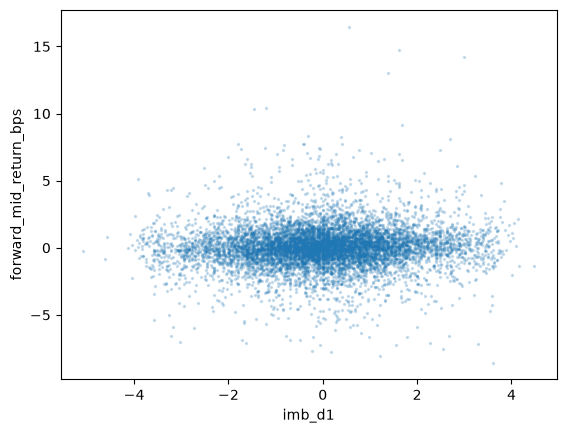

imb_d3 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d3   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.043774 ┆ 1.565148               │
└──────────┴────────────────────────┘


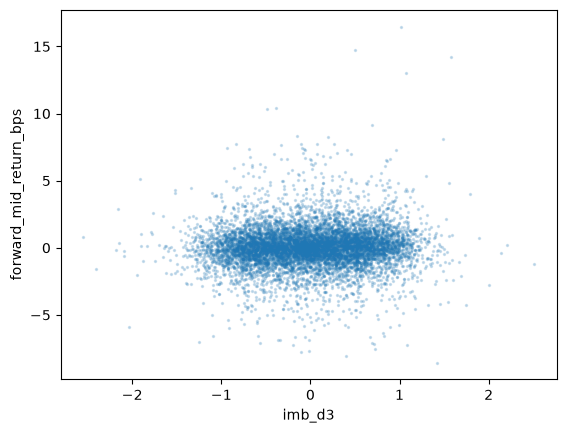

imb_d5 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d5   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.043573 ┆ 1.565148               │
└──────────┴────────────────────────┘


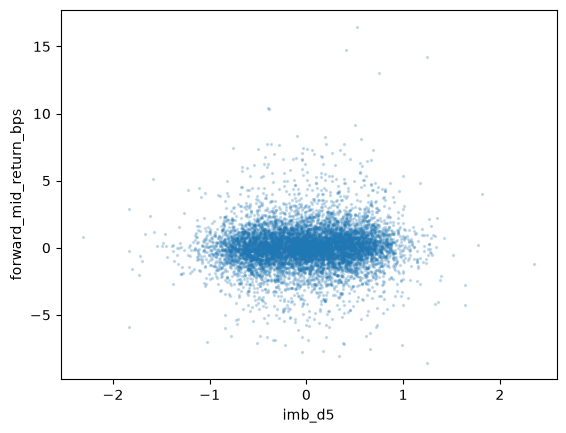

weighted_price_sz2 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz2 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.028587           ┆ 1.565148               │
└────────────────────┴────────────────────────┘


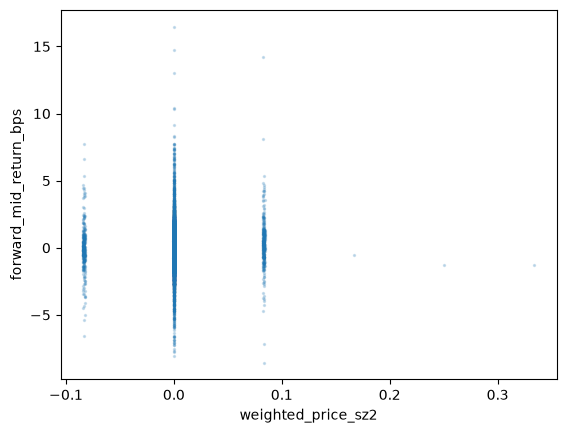

weighted_price_sz5 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz5 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.044205           ┆ 1.565148               │
└────────────────────┴────────────────────────┘


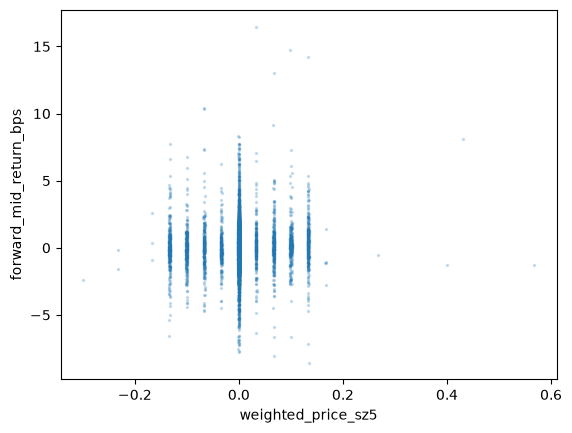

weighted_price_sz10 shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ weighted_price_sz10 ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ 0.048794            ┆ 1.565148               │
└─────────────────────┴────────────────────────┘


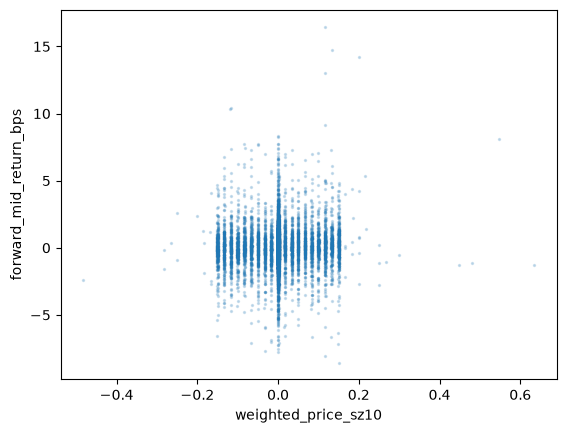

trade_momentum_hl1s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ trade_momentum_hl1s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.011032           ┆ 1.565148               │
└─────────────────────┴────────────────────────┘


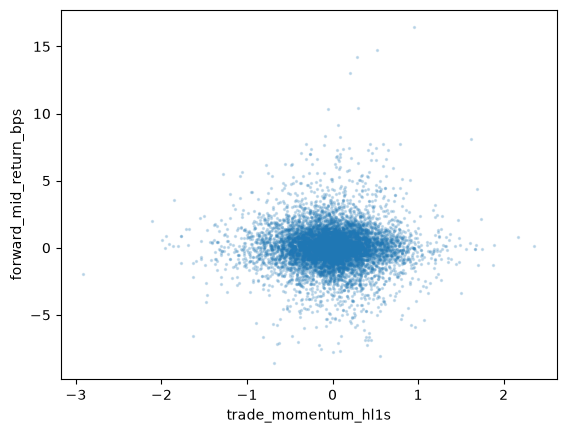

push_momentum_hl1s shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ push_momentum_hl1s ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ -0.018632          ┆ 1.565148               │
└────────────────────┴────────────────────────┘


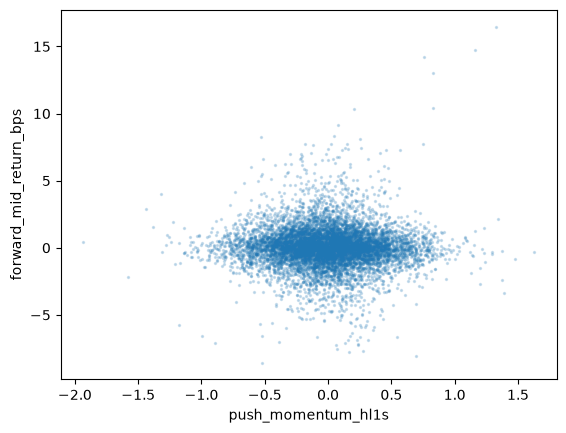

pull_momentum_hl1s shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ pull_momentum_hl1s ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.00019            ┆ 1.565148               │
└────────────────────┴────────────────────────┘


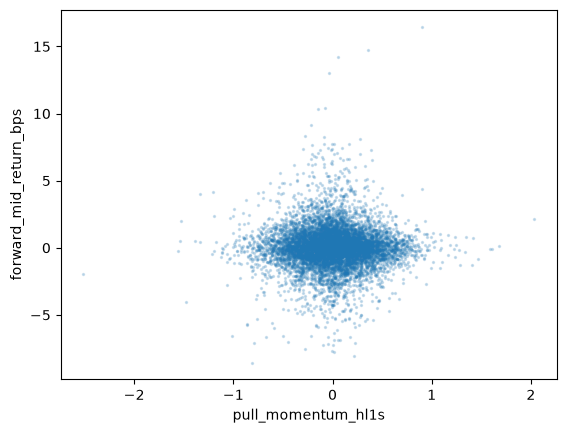

trade_corr_side_hl1s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_corr_side_hl1s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ 0.011981             ┆ 1.565148               │
└──────────────────────┴────────────────────────┘


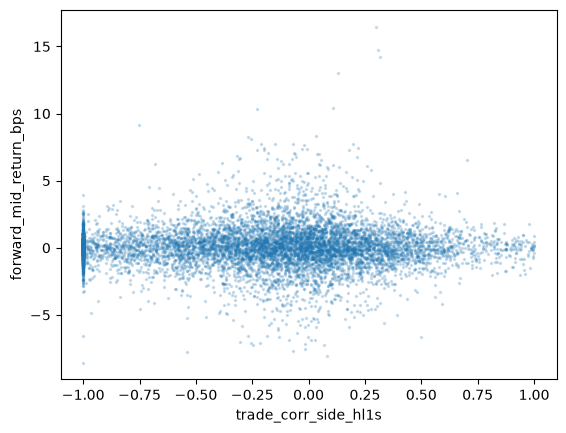

trade_corr_volume_hl1s shape: (1, 2)
┌────────────────────────┬────────────────────────┐
│ trade_corr_volume_hl1s ┆ forward_mid_return_bps │
│ ---                    ┆ ---                    │
│ f64                    ┆ f64                    │
╞════════════════════════╪════════════════════════╡
│ 0.017579               ┆ 1.565148               │
└────────────────────────┴────────────────────────┘


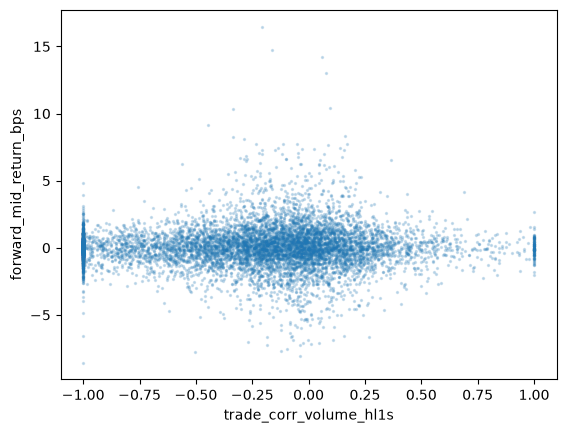

log_return_hl1s shape: (1, 2)
┌─────────────────┬────────────────────────┐
│ log_return_hl1s ┆ forward_mid_return_bps │
│ ---             ┆ ---                    │
│ f64             ┆ f64                    │
╞═════════════════╪════════════════════════╡
│ -0.056228       ┆ 1.565148               │
└─────────────────┴────────────────────────┘


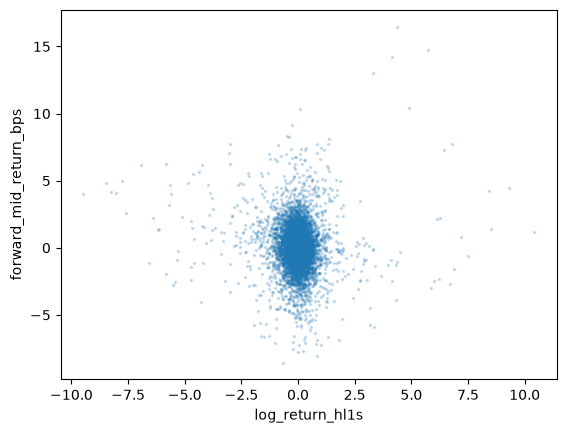

ewma_spread_hl1s shape: (1, 2)
┌──────────────────┬────────────────────────┐
│ ewma_spread_hl1s ┆ forward_mid_return_bps │
│ ---              ┆ ---                    │
│ f64              ┆ f64                    │
╞══════════════════╪════════════════════════╡
│ 0.022139         ┆ 1.565148               │
└──────────────────┴────────────────────────┘


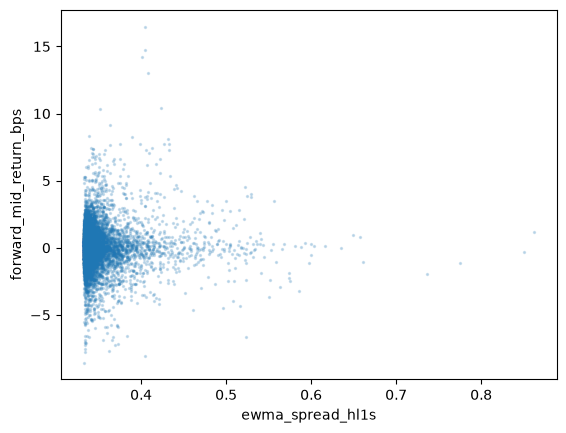

trade_momentum_hl10s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl10s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.047033            ┆ 1.565148               │
└──────────────────────┴────────────────────────┘


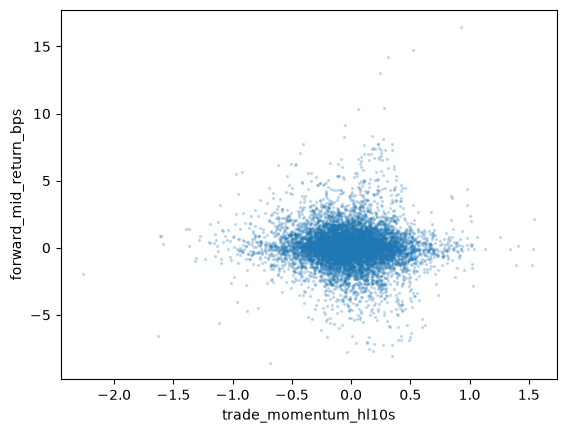

push_momentum_hl10s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ push_momentum_hl10s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.053063           ┆ 1.565148               │
└─────────────────────┴────────────────────────┘


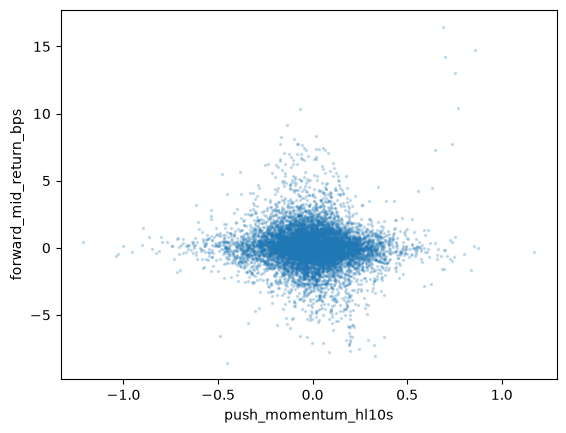

pull_momentum_hl10s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ pull_momentum_hl10s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.016537           ┆ 1.565148               │
└─────────────────────┴────────────────────────┘


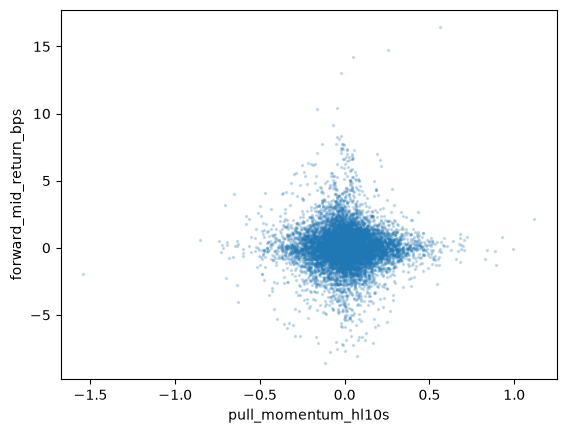

trade_corr_side_hl10s shape: (1, 2)
┌───────────────────────┬────────────────────────┐
│ trade_corr_side_hl10s ┆ forward_mid_return_bps │
│ ---                   ┆ ---                    │
│ f64                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ -0.009281             ┆ 1.565148               │
└───────────────────────┴────────────────────────┘


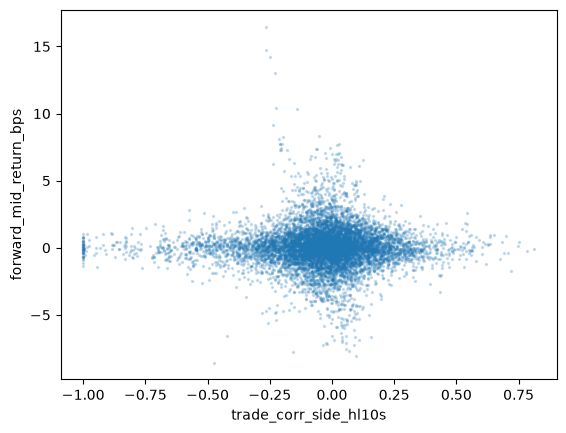

trade_corr_volume_hl10s shape: (1, 2)
┌─────────────────────────┬────────────────────────┐
│ trade_corr_volume_hl10s ┆ forward_mid_return_bps │
│ ---                     ┆ ---                    │
│ f64                     ┆ f64                    │
╞═════════════════════════╪════════════════════════╡
│ 0.001907                ┆ 1.565148               │
└─────────────────────────┴────────────────────────┘


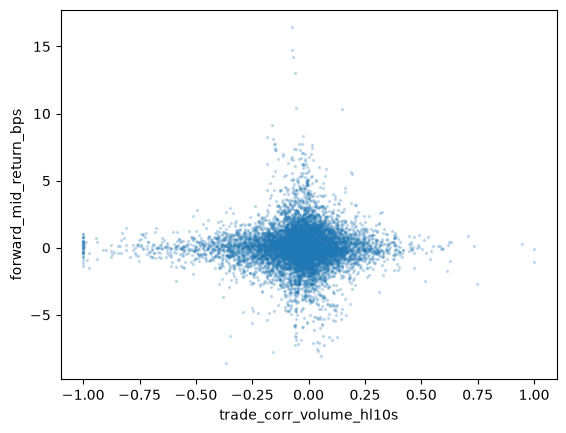

log_return_hl10s shape: (1, 2)
┌──────────────────┬────────────────────────┐
│ log_return_hl10s ┆ forward_mid_return_bps │
│ ---              ┆ ---                    │
│ f64              ┆ f64                    │
╞══════════════════╪════════════════════════╡
│ -0.139825        ┆ 1.565148               │
└──────────────────┴────────────────────────┘


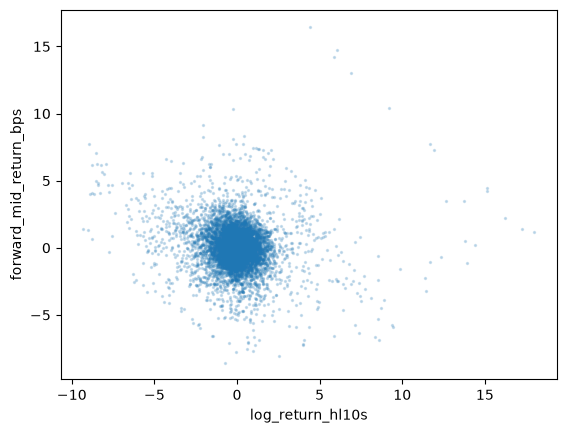

ewma_spread_hl10s shape: (1, 2)
┌───────────────────┬────────────────────────┐
│ ewma_spread_hl10s ┆ forward_mid_return_bps │
│ ---               ┆ ---                    │
│ f64               ┆ f64                    │
╞═══════════════════╪════════════════════════╡
│ -0.008275         ┆ 1.565148               │
└───────────────────┴────────────────────────┘


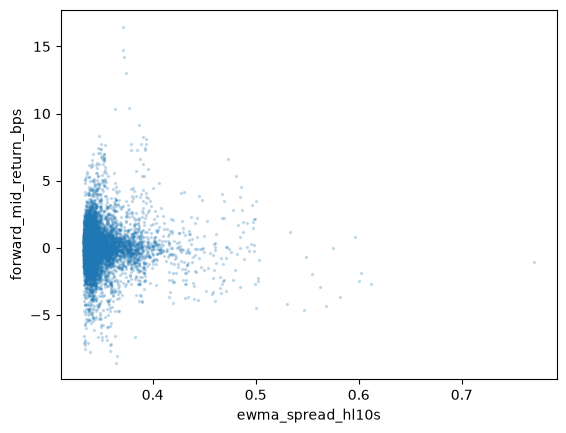

trade_momentum_hl30s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl30s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.053476            ┆ 1.565148               │
└──────────────────────┴────────────────────────┘


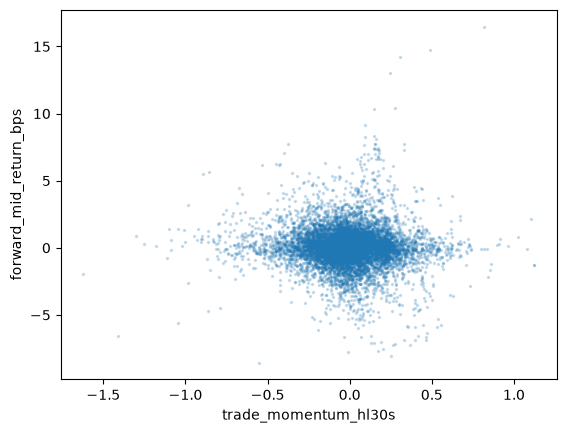

push_momentum_hl30s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ push_momentum_hl30s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.071279           ┆ 1.565148               │
└─────────────────────┴────────────────────────┘


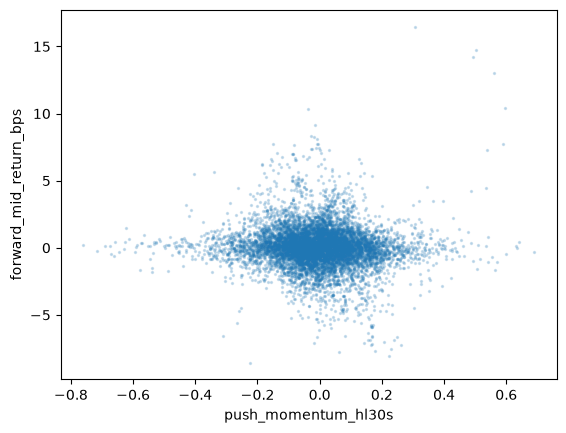

pull_momentum_hl30s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ pull_momentum_hl30s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.014817           ┆ 1.565148               │
└─────────────────────┴────────────────────────┘


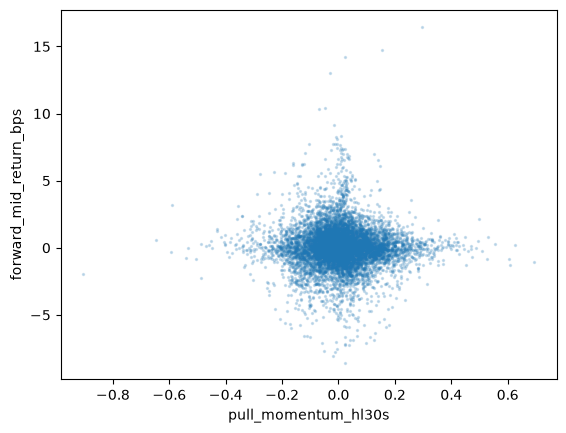

trade_corr_side_hl30s shape: (1, 2)
┌───────────────────────┬────────────────────────┐
│ trade_corr_side_hl30s ┆ forward_mid_return_bps │
│ ---                   ┆ ---                    │
│ f64                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ -0.010887             ┆ 1.565148               │
└───────────────────────┴────────────────────────┘


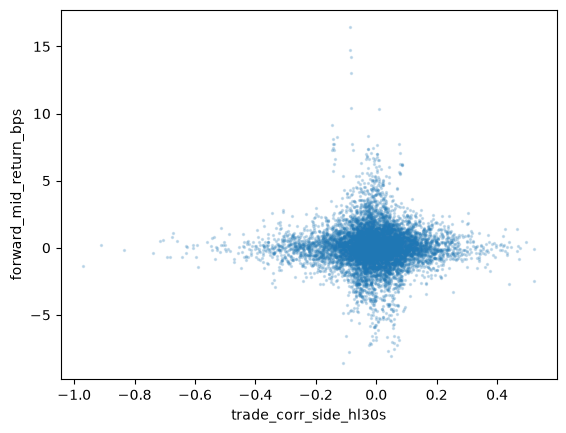

trade_corr_volume_hl30s shape: (1, 2)
┌─────────────────────────┬────────────────────────┐
│ trade_corr_volume_hl30s ┆ forward_mid_return_bps │
│ ---                     ┆ ---                    │
│ f64                     ┆ f64                    │
╞═════════════════════════╪════════════════════════╡
│ -0.007513               ┆ 1.565148               │
└─────────────────────────┴────────────────────────┘


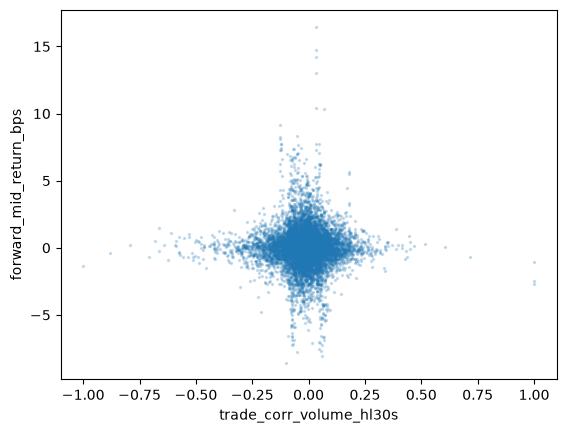

log_return_hl30s shape: (1, 2)
┌──────────────────┬────────────────────────┐
│ log_return_hl30s ┆ forward_mid_return_bps │
│ ---              ┆ ---                    │
│ f64              ┆ f64                    │
╞══════════════════╪════════════════════════╡
│ -0.150105        ┆ 1.565148               │
└──────────────────┴────────────────────────┘


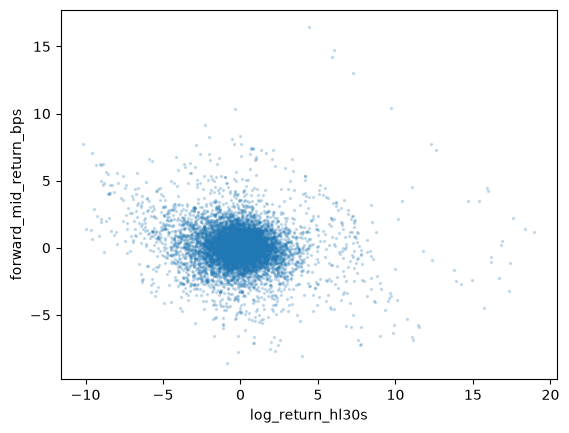

ewma_spread_hl30s shape: (1, 2)
┌───────────────────┬────────────────────────┐
│ ewma_spread_hl30s ┆ forward_mid_return_bps │
│ ---               ┆ ---                    │
│ f64               ┆ f64                    │
╞═══════════════════╪════════════════════════╡
│ -0.032152         ┆ 1.565148               │
└───────────────────┴────────────────────────┘


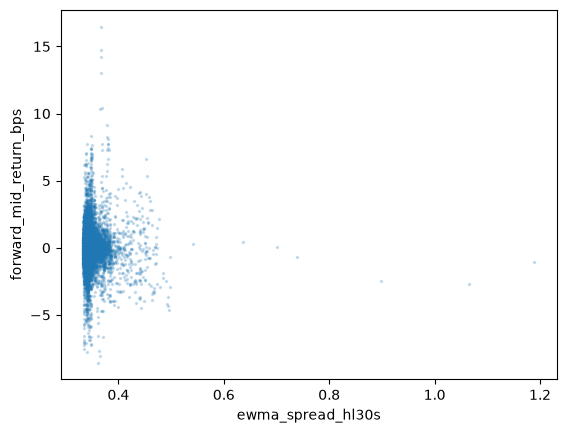

trade_momentum_hl120s shape: (1, 2)
┌───────────────────────┬────────────────────────┐
│ trade_momentum_hl120s ┆ forward_mid_return_bps │
│ ---                   ┆ ---                    │
│ f64                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ -0.0519               ┆ 1.565148               │
└───────────────────────┴────────────────────────┘


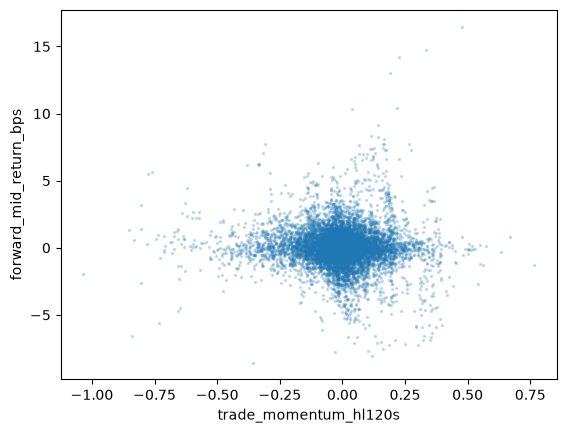

push_momentum_hl120s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ push_momentum_hl120s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.060229            ┆ 1.565148               │
└──────────────────────┴────────────────────────┘


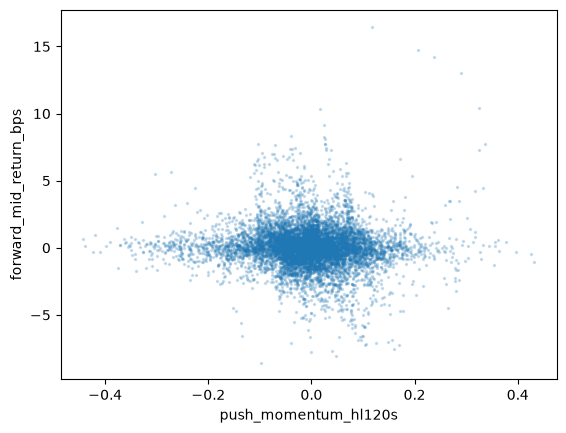

pull_momentum_hl120s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ pull_momentum_hl120s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ -0.018952            ┆ 1.565148               │
└──────────────────────┴────────────────────────┘


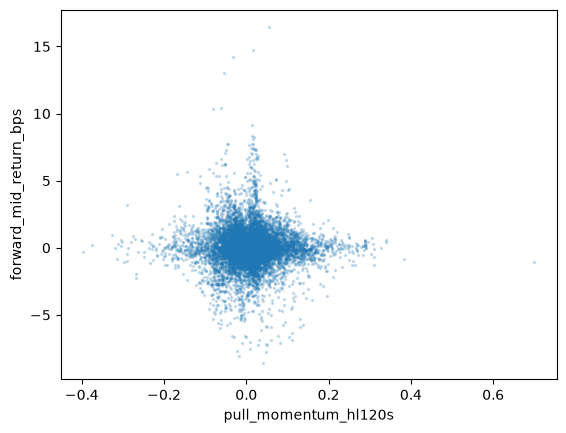

trade_corr_side_hl120s shape: (1, 2)
┌────────────────────────┬────────────────────────┐
│ trade_corr_side_hl120s ┆ forward_mid_return_bps │
│ ---                    ┆ ---                    │
│ f64                    ┆ f64                    │
╞════════════════════════╪════════════════════════╡
│ -0.014833              ┆ 1.565148               │
└────────────────────────┴────────────────────────┘


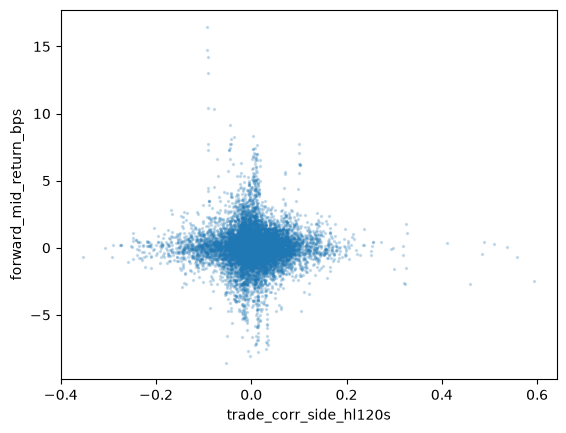

trade_corr_volume_hl120s shape: (1, 2)
┌──────────────────────────┬────────────────────────┐
│ trade_corr_volume_hl120s ┆ forward_mid_return_bps │
│ ---                      ┆ ---                    │
│ f64                      ┆ f64                    │
╞══════════════════════════╪════════════════════════╡
│ -0.043884                ┆ 1.565148               │
└──────────────────────────┴────────────────────────┘


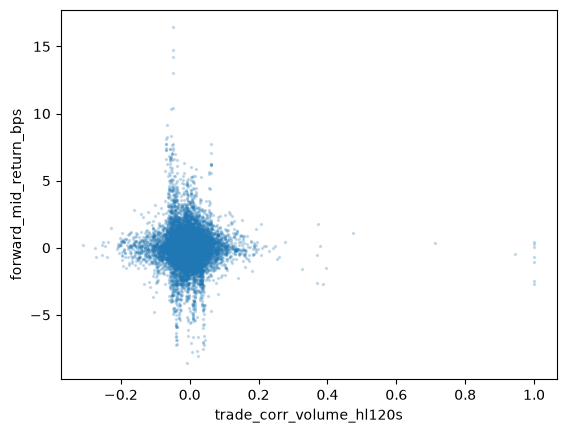

log_return_hl120s shape: (1, 2)
┌───────────────────┬────────────────────────┐
│ log_return_hl120s ┆ forward_mid_return_bps │
│ ---               ┆ ---                    │
│ f64               ┆ f64                    │
╞═══════════════════╪════════════════════════╡
│ -0.14986          ┆ 1.565148               │
└───────────────────┴────────────────────────┘


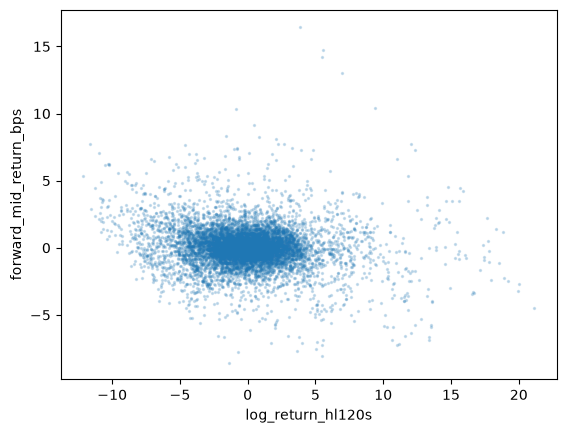

ewma_spread_hl120s shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ ewma_spread_hl120s ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ -0.029201          ┆ 1.565148               │
└────────────────────┴────────────────────────┘


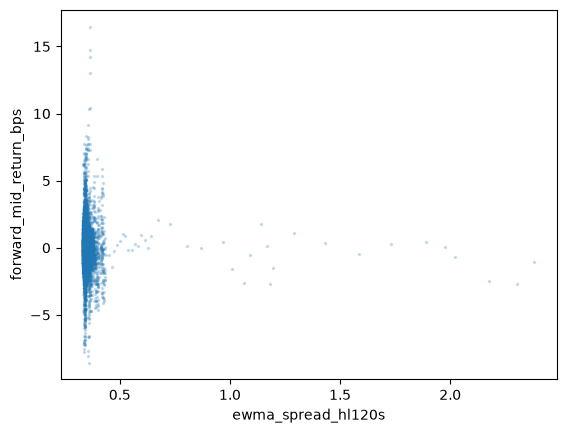

In [12]:
corr = np.zeros((len(FEATURES), len(FEATURES)))
for i, feature_i in enumerate(FEATURES):
    for j, feature_j in enumerate(FEATURES):
        corr[i, j] = df.select(pl.corr(pl.col(feature_i), pl.col(feature_j)))[0].item()
print(corr)

for feature in FEATURES:
    print(feature, df.select(pl.corr(pl.col(feature), pl.col(TARGET)), pl.col(TARGET).std()))
    plt.scatter(df[feature], df[TARGET], s=2, alpha=0.2)
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.show()

In [ ]:
train_result = pipeline.train(verbose=2, no_refit=True)
train_result

[I 2026-07-06 18:57:28,003] A new study created in memory with name: no-name-94a98bd7-da57-4950-901e-d95a3428d7a0


======== Optuna study created. Launching optimization.
======== running params {'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cuda', 'seed': 7, 'max_depth': 2, 'eta': 0.01, 'subsample': 0.9119675168960458, 'colsample_bytree': 0.7192046157204468, 'min_child_weight': 27.98532505338013, 'lambda': 77.61533923098803, 'alpha': 0.04925829235993477}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


Loading data: 7.08Mrow [00:20, 340krow/s]
Loading data: 7.08Mrow [00:21, 331krow/s]
Loading data: 7.08Mrow [00:19, 368krow/s]
Loading data: 7.08Mrow [00:18, 379krow/s]
Loading data: 3.73Mrow [00:12, 298krow/s]
Loading data: 3.73Mrow [00:12, 302krow/s]
Loading data: 3.73Mrow [00:11, 335krow/s]
/home/jli/projects/rep/tools/pipeline.py:1041: RuntimeWarning: XGBoost pruning requested, but optuna-integration is not installed; continuing without pruning callback.
  return self.adapter.fit(model, train, val, self.tracker, **kwargs)
Loading data: 200krow [00:00, 251krow/s]/home/jli/projects/rep/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [19:01:10] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordin

======== loss = 0.5571692564486618, running average = 0.5571692564486618
======== fold: 1, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'] and val = ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08']


Loading data: 10.8Mrow [00:31, 348krow/s]
Loading data: 10.8Mrow [00:34, 312krow/s]
Loading data: 10.8Mrow [00:33, 327krow/s]
Loading data: 10.8Mrow [00:32, 329krow/s]
Loading data: 3.13Mrow [00:11, 277krow/s]
Loading data: 3.13Mrow [00:10, 303krow/s]
Loading data: 3.13Mrow [00:09, 348krow/s]
Loading data: 3.13Mrow [00:10, 294krow/s]


...

Loading data: 10.8Mrow [00:32, 335krow/s]
Loading data: 10.8Mrow [00:33, 324krow/s]
Loading data: 10.8Mrow [00:34, 309krow/s]
Loading data: 10.8Mrow [00:32, 330krow/s]
Loading data: 3.13Mrow [00:11, 273krow/s]
Loading data: 3.13Mrow [00:11, 270krow/s]
Loading data: 3.13Mrow [00:10, 309krow/s]
Loading data: 3.13Mrow [00:11, 271krow/s]


======== loss = 0.4614208163214415, running average = 0.5073733172222687
======== fold: 2, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'] and val = ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']


Loading data: 13.9Mrow [00:42, 325krow/s]
Loading data: 13.9Mrow [00:46, 297krow/s]
Loading data: 13.9Mrow [00:46, 297krow/s]
Loading data: 13.9Mrow [00:43, 320krow/s]
Loading data: 4.23Mrow [00:14, 301krow/s]
Loading data: 4.23Mrow [00:13, 304krow/s]
Loading data: 4.23Mrow [00:12, 345krow/s]
Loading data: 4.23Mrow [00:13, 322krow/s]
[I 2026-07-06 20:22:08,013] Trial 5 finished with value: 0.553116359077024 and parameters: {'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cuda', 'seed': 7, 'max_depth': 3, 'eta': 0.01, 'subsample': 0.7963063556364282, 'colsample_bytree': 0.6861923446925295, 'min_child_weight': 9.011608369599195, 'lambda': 0.06752303101068005, 'alpha': 1.5473550318638905}. Best is trial 1 with value: 0.5530923667826562.


======== loss = 0.6053729366396993, running average = 0.553116359077024
======== running params {'eval_metric': 'quantile', 'tree_method': 'hist', 'device': 'cuda', 'seed': 7, 'max_depth': 5, 'eta': 0.01, 'subsample': 0.7255978708850649, 'colsample_bytree': 0.786312666321977, 'min_child_weight': 3.565316562441851, 'lambda': 0.183744633044491, 'alpha': 0.005819582506376546}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


Loading data: 7.08Mrow [00:20, 347krow/s]
Loading data: 7.08Mrow [00:21, 330krow/s]
Loading data: 7.08Mrow [00:20, 351krow/s]
Loading data: 7.08Mrow [00:18, 381krow/s]
Loading data: 3.73Mrow [00:12, 290krow/s]
Loading data: 3.73Mrow [00:13, 284krow/s]
Loading data: 3.73Mrow [00:11, 324krow/s]


In [ ]:
best_trial_attrs = pipeline.study.best_trial.user_attrs
xgb_fits = pl.DataFrame(best_trial_attrs.get("xgb_fits", []))
cv_rounds = [int(x) for x in best_trial_attrs.get("xgb_cv_best_num_boost_rounds", [])]
refit_num_boost_round = min(NUM_BOOST_ROUND, max(cv_rounds)) if cv_rounds else NUM_BOOST_ROUND
xgb_round_summary = {
    "median": best_trial_attrs.get("xgb_cv_best_num_boost_round_median"),
    "max": best_trial_attrs.get("xgb_cv_best_num_boost_round_max"),
    "refit": refit_num_boost_round,
    "fold_rounds": cv_rounds,
}
xgb_round_summary, xgb_fits

In [ ]:
from tools.pipeline import plot_train_val_loss
plot_train_val_loss(train_result["validation_history"])

In [ ]:
refit_num_boost_round

In [ ]:
refit_dates = [date for dates in ROLLING_DATES for date in dates]
pipeline.adapter.num_boost_round = refit_num_boost_round
refit_result = pipeline.refit(refit_dates)
print(f"refit_num_boost_round = {refit_num_boost_round}")
pipeline.get_model()

In [ ]:
pipeline.save_pipeline('./dump/')

In [ ]:
rmse_result = pipeline.test(median_quantile(rmse))
rmse_result

In [ ]:
pinball_result = pipeline.test(get_pinball(QUANTILES))

interval_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)
y_true_test, _ = interval_src.labels()
y_pred_q = pinball_result["y_pred"]
lo, hi = y_pred_q[:, 0], y_pred_q[:, -1]
coverage = float(np.mean((y_true_test >= lo) & (y_true_test <= hi)))
width = float(np.mean(hi - lo))
target_coverage = QUANTILES[-1] - QUANTILES[0]
print(f"pinball = {pinball_result['test_score']:.6f}")
print(f"interval coverage = {coverage:.4f} (target {target_coverage:.2f})")
print(f"mean interval width = {width:.4f} bps")

In [ ]:
pnl_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.1),
        q_sell=QUANTILES.index(0.9),
        thd_buy=-1.0,
        thd_sell=1.0,
    ),
    keep_predictions=False,
)
pnl_result

In [ ]:
pnl_threshold_result = pipeline.test(
    get_quantile_pnl(
        q_buy=QUANTILES.index(0.5),
        q_sell=QUANTILES.index(0.5),
        thd_buy=1.5,
        thd_sell=-1.5,
    ),
    keep_predictions=False,
)
pnl_threshold_result

In [ ]:
y_pred_q = rmse_result["y_pred"]
print(np.mean(y_pred_q, axis=0), np.std(y_pred_q, axis=0))
_ = plt.hist(y_pred_q[:, 1:-1], bins=100, log=True, density=False, label=[f"q={q}" for q in QUANTILES[1:-1]])
plt.legend()
plt.xlabel("prediction")
plt.ylabel("count")

In [ ]:
booster = pipeline.get_model()
gain = booster.get_score(importance_type="gain")
weight = booster.get_score(importance_type="weight")

df_importance = pl.DataFrame(
    [
        {
            "feature": feature,
            "gain": float(gain.get(f"f{idx}", gain.get(feature, 0.0))),
            "weight": float(weight.get(f"f{idx}", weight.get(feature, 0.0))),
        }
        for idx, feature in enumerate(FEATURES)
    ]
).sort("gain", descending=True)

df_importance

In [ ]:
# test_src = DataSource(
#     dates=TEST_DATES,
#     loader=regular_loader,
#     target=TARGET,
#     features=FEATURES,
#     filters=(VALID_REGULAR_ROWS,),
#     polars_engine=POLARS_ENGINE,
# )
# y_true, _ = test_src.labels()
# pred_eval = pl.DataFrame({"y_true": y_true, "y_pred": pnl_threshold_result["y_pred"][:, MEDIAN_IDX]})
# n_pred = pred_eval.height
# pred_eval = pred_eval.with_columns(
#     (((pl.col("y_pred").rank("average") - 1) * 10 / n_pred).floor().clip(0, 9).cast(pl.Int8)).alias("pred_decile")
# )

# pred_eval.group_by("pred_decile").agg(
#     pl.len().alias("n"),
#     pl.col("y_pred").mean().alias("mean_pred"),
#     pl.col("y_true").mean().alias("mean_forward_return_bps"),
#     (pl.col("y_true") * pl.col("y_pred").sign()).mean().alias("mean_signed_return_bps"),
# ).sort("pred_decile")

In [ ]:
import pandas as pd
import shap

# Keep these bounded; the full test split is too large for SHAP interaction arrays.
SHAP_SAMPLE_ROWS = 25_000
SHAP_INTERACTION_ROWS = 5_000
SHAP_RANDOM_SEED = SEED
SHAP_BATCH_SIZE = MODEL_BATCH_SIZE
SHAP_TOP_K = 5  # dependence plots for top-k features by mean |SHAP|; interaction plots for top-k pairs


def sample_stream_rows(src, max_rows: int, batch_size: int, seed: int):
    total_rows = src.count()
    sample_rows = min(int(max_rows), total_rows)
    if sample_rows <= 0:
        raise ValueError("cannot build SHAP sample from an empty test source")

    rng = np.random.default_rng(seed)
    sample_pos = np.sort(rng.choice(total_rows, size=sample_rows, replace=False))
    x_parts = []
    y_parts = []
    offset = 0
    cursor = 0

    for x, y, _ in src.batches(batch_size):
        n = len(y)
        end = offset + n
        next_cursor = np.searchsorted(sample_pos, end, side="left")
        if next_cursor > cursor:
            local_pos = sample_pos[cursor:next_cursor] - offset
            x_parts.append(np.asarray(x[local_pos], dtype=np.float32))
            y_parts.append(np.asarray(y[local_pos]))
        offset = end
        cursor = next_cursor
        if cursor >= sample_rows:
            break

    if not x_parts:
        raise ValueError("SHAP sampler did not collect any rows")
    return np.vstack(x_parts), np.concatenate(y_parts), total_rows


shap_test_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

X_shap, y_shap, shap_total_rows = sample_stream_rows(
    shap_test_src,
    max_rows=SHAP_SAMPLE_ROWS,
    batch_size=SHAP_BATCH_SIZE,
    seed=SHAP_RANDOM_SEED,
)
X_shap_df = pd.DataFrame(X_shap, columns=FEATURES)
print(f"Sampled {len(X_shap_df):,} of {shap_total_rows:,} streamed test rows for SHAP.")

booster = pipeline.get_model()
shap_explainer = shap.TreeExplainer(booster)
shap_values = shap_explainer.shap_values(X_shap_df)
if isinstance(shap_values, list):
    shap_values = shap_values[MEDIAN_IDX]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    # Multi-quantile booster: (n, features, quantiles); explain the median output.
    shap_values = shap_values[..., MEDIAN_IDX]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1]
top_k = min(int(SHAP_TOP_K), len(FEATURES))
top_features = [FEATURES[int(idx)] for idx in feature_order[:top_k]]
print(f"Top {top_k} features by mean |SHAP|: {top_features}")

shap.summary_plot(shap_values, X_shap_df, max_display=top_k, show=False)
plt.title(f"SHAP feature impact on streamed test sample (top {top_k})")
plt.tight_layout()
plt.show()

for feature in top_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_shap_df,
        interaction_index=None,
        show=False,
    )
    plt.title(f"SHAP dependence: {feature}")
    plt.tight_layout()
    plt.show()

interaction_rows = min(int(SHAP_INTERACTION_ROWS), len(X_shap_df))
X_interaction_df = X_shap_df.iloc[:interaction_rows].copy()
shap_interaction_values = shap_explainer.shap_interaction_values(X_interaction_df)
if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[MEDIAN_IDX]
shap_interaction_values = np.asarray(shap_interaction_values)
if shap_interaction_values.ndim == 4:
    shap_interaction_values = shap_interaction_values[..., MEDIAN_IDX]
if shap_interaction_values.shape[1:] != (len(FEATURES), len(FEATURES)):
    raise ValueError(
        "unexpected SHAP interaction shape "
        f"{shap_interaction_values.shape}; expected (*, {len(FEATURES)}, {len(FEATURES)})"
    )

mean_abs_interaction = np.abs(shap_interaction_values).mean(axis=0)
mean_abs_interaction_no_diag = mean_abs_interaction.copy()
np.fill_diagonal(mean_abs_interaction_no_diag, 0.0)

# Interaction matrix is symmetric; rank unique upper-triangle pairs.
iu, ju = np.triu_indices(len(FEATURES), k=1)
pair_order = np.argsort(mean_abs_interaction_no_diag[iu, ju])[::-1]
top_pairs = [(int(iu[idx]), int(ju[idx])) for idx in pair_order[:top_k]]
print(f"Top {len(top_pairs)} interaction pairs on {interaction_rows:,} rows:")
for i, j in top_pairs:
    print(f"  {FEATURES[i]} x {FEATURES[j]}: {mean_abs_interaction_no_diag[i, j]:.6f}")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mean_abs_interaction_no_diag, cmap="viridis")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.set_title("Mean absolute SHAP interaction")
fig.colorbar(im, ax=ax, label="mean |interaction SHAP|")
fig.tight_layout()
plt.show()

for i, j in top_pairs:
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        X_interaction_df[FEATURES[i]],
        shap_interaction_values[:, i, j],
        c=X_interaction_df[FEATURES[j]],
        s=7,
        alpha=0.35,
        cmap="viridis",
    )
    ax.set_xlabel(FEATURES[i])
    ax.set_ylabel(f"SHAP interaction: {FEATURES[i]} x {FEATURES[j]}")
    ax.set_title(f"SHAP interaction dependence: {FEATURES[i]} x {FEATURES[j]}")
    fig.colorbar(scatter, ax=ax, label=FEATURES[j])
    fig.tight_layout()
    plt.show()